#Exercise 1: Image Processing using PIL

Import library

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

1. Read and Display the Image

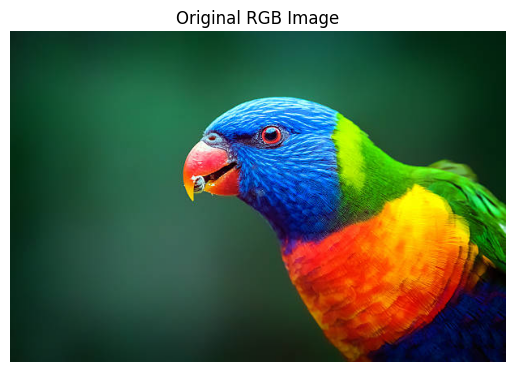

In [5]:
image = Image.open("parrot.jpg")

plt.imshow(image)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

2. Display the Top Left Corner (100 × 100)

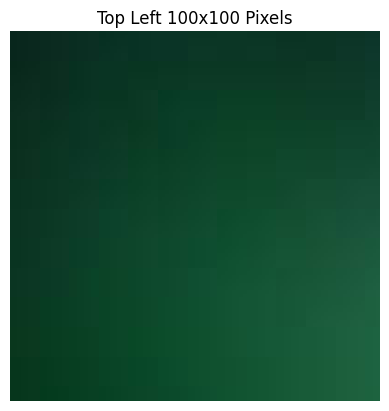

In [6]:
img_array = np.array(image)

top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Display the Three Color Channels (R, G, B)

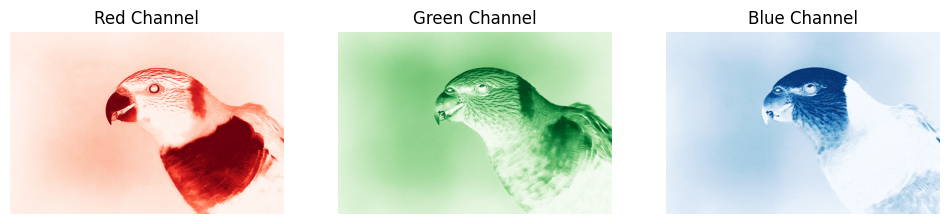

In [7]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4. Modify the Top 100 × 100 Pixels to Value 210

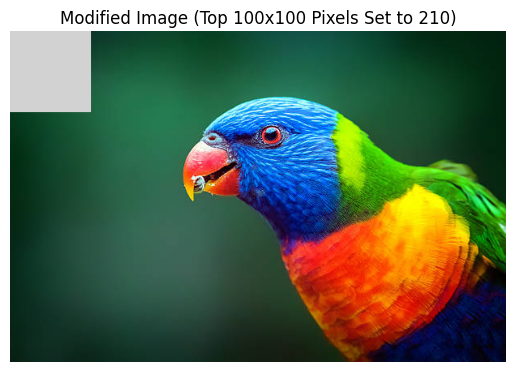

In [8]:
modified = img_array.copy()

modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 Pixels Set to 210)")
plt.axis("off")
plt.show()

#Exercise 2: Grayscale Image Processing

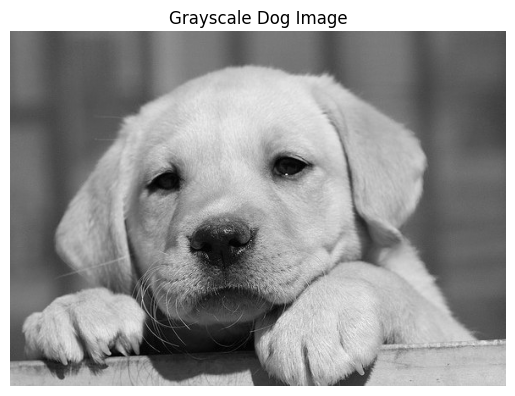

In [9]:
gray_img = Image.open("dog_grayscale.jpg")

plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Dog Image")
plt.axis("off")
plt.show()

2. Extract the Middle Section (150 × 150 Pixels)

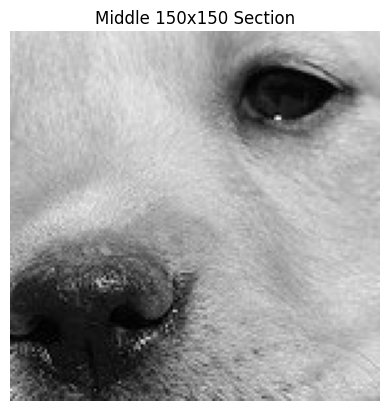

In [10]:
gray_array = np.array(gray_img)

h, w = gray_array.shape

middle_section = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply Threshold

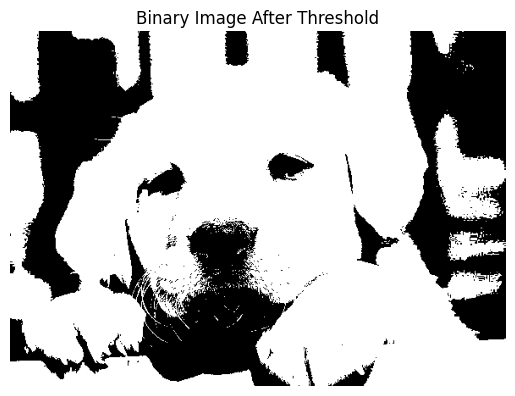

In [11]:
threshold_img = np.where(gray_array < 100, 0, 255)

plt.imshow(threshold_img, cmap="gray")
plt.title("Binary Image After Threshold")
plt.axis("off")
plt.show()

4. Rotate the Image 90° Clockwise

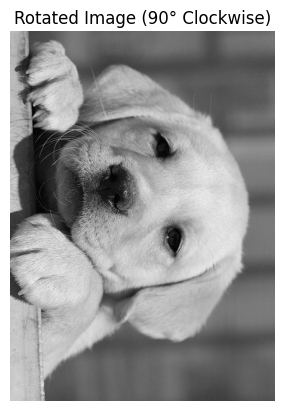

In [12]:
rotated_img = gray_img.rotate(-90, expand=True)

plt.imshow(rotated_img, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert Grayscale Image to RGB

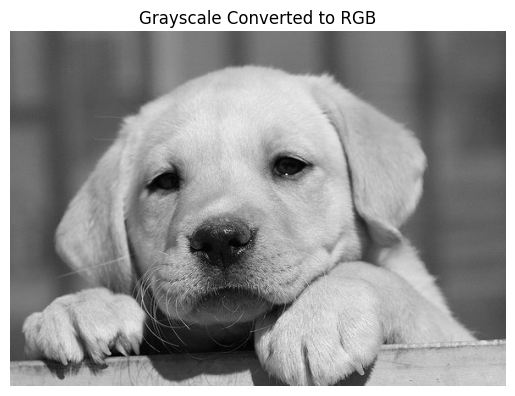

In [13]:
rgb_img = gray_img.convert("RGB")

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

#Exercise 3: Image Compression using PCA

1. Load Image

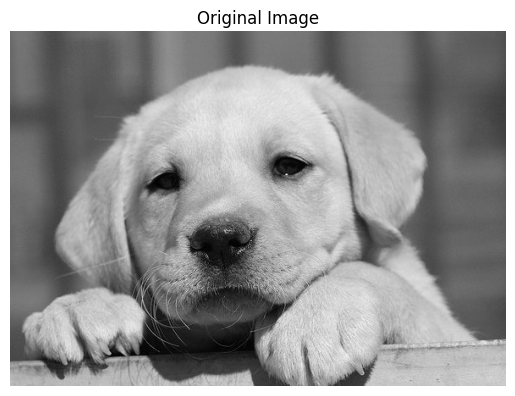

In [14]:
img = Image.open("dog_grayscale.jpg").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Standardize Data

In [15]:
mean = np.mean(img_array, axis=0)

centered = img_array - mean

3. Compute Covariance Matrix

In [16]:
cov_matrix = np.cov(centered, rowvar=False)

4. Eigenvalues and Eigenvectors

In [17]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

5. Explained Variance Plot

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


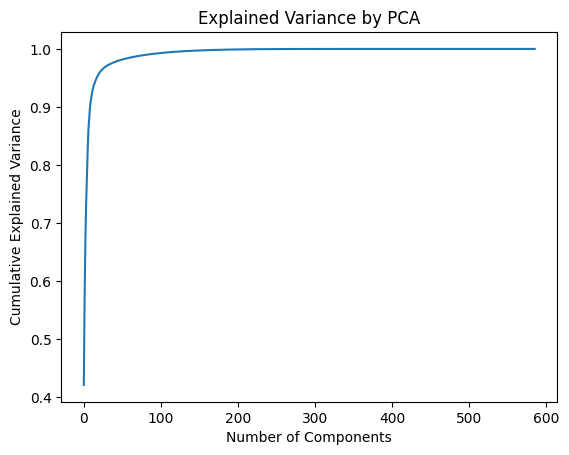

In [18]:
explained_variance = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")
plt.show()

6. Image Reconstruction Using Different k Values

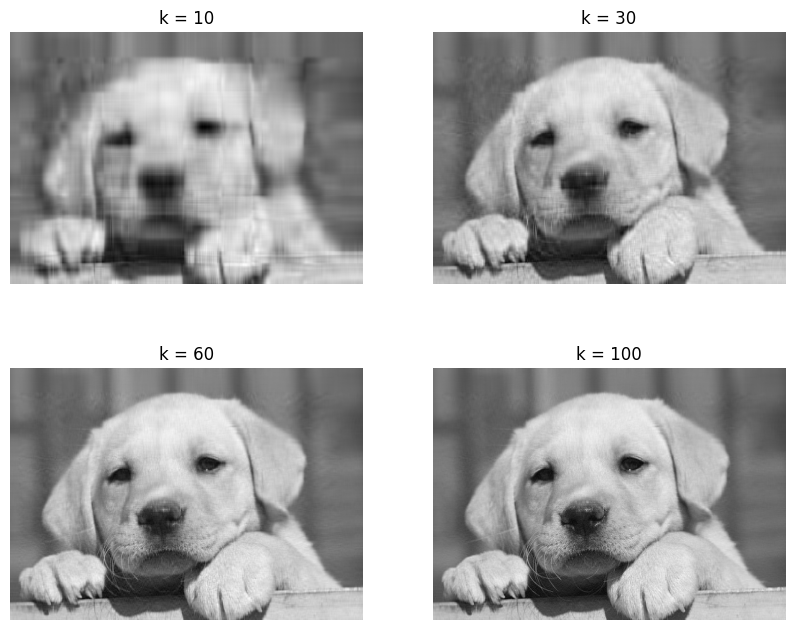

In [20]:
k_values = [10, 30, 60, 100]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):

    pcs = eigenvectors[:, :k]

    compressed = np.dot(centered, pcs)

    reconstructed = np.dot(compressed, pcs.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(np.real(reconstructed), cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()

Conclusion

In this worksheet, various image processing techniques were applied using Python libraries such as PIL, NumPy, and Matplotlib. RGB image manipulation, grayscale processing, thresholding, and rotation were performed. PCA was implemented from scratch to compress the grayscale image while preserving important visual information.